# Feature Drop A/B Comparison

This notebook runs a minimal, fair A/B experiment to see how removing selected features affects a classifier’s performance.

**Overview**
- Load a prepared dataframe `df` with a target column (e.g., `label`).
- Train **two models** on the **same train/test split**:
  1) **All features**
  2) **Without selected features** (`PROBLEM_FEATURES`)
- Evaluate using **ROC AUC** and **PR AUC**, with an optional thresholded report.

**Use cases**
- Detect and mitigate noisy, sentinel-filled, or high-leakage features.
- Quantify whether dropping specific columns helps or hurts performance.

**How to run**
1. Load `df` (adjust the file reader as needed).
2. Set `PROBLEM_FEATURES` to the columns you want to exclude.
3. Run cells top-to-bottom and compare the printed metrics (ΔAUC).


## Imports

In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

## 1. Load the dataframe 

In [3]:
# The file path of the saved CSV file
file_path = Path('./dataframes/phishing_extracted_features.csv')

try:
    df = pd.read_csv(file_path)
    df.head()

except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}. Ensure the saving step was executed.")

except Exception as e:
    print(f"An unexpected error occurred: {e}")

## 2. Choose features to exclude from training

In [9]:
# Labels
label_map = {"benign": 0, "phishing": 1}
y = df["label"].map(label_map).astype("int8")

# Features (all) and the list to drop for the comparison
X_all = df.drop(columns=["label"])

PROBLEM_FEATURES = [
    # "rdap_domain_age",
    "lex_tld_abuse_score",
    # "rdap_registrar_name_len",
    "tls_leaf_cert_validity_len",
    "rdap_domain_active_time",
    "tls_root_authority_hash",
    "lex_tld_len",
    # "rdap_registrar_name_entropy",
    "tls_critical_extensions",
    "tls_percentage_crt_with_policies",
]

X_drop = X_all.drop(columns=PROBLEM_FEATURES, errors="ignore")

print("All features:", X_all.shape[1], "| After drop:", X_drop.shape[1])


All features: 173 | After drop: 166


## 3. Train two models (same split): with all features vs without

In [10]:
# Single, shared split for a fair A/B comparison
idx_train, idx_test = train_test_split(
    df.index, test_size=0.2, random_state=42, stratify=y
)

def train_model(X):
    clf = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        n_jobs=-1,
        tree_method="hist",
        random_state=42,
    )
    clf.fit(X.loc[idx_train], y.loc[idx_train])
    return clf

model_all  = train_model(X_all)
model_drop = train_model(X_drop)

## 4. Evaluate (ROC AUC, PR AUC, and a quick thresholded report)

In [11]:
def evaluate(model, X, name):
    proba = model.predict_proba(X.loc[idx_test])[:, 1]
    auc   = roc_auc_score(y.loc[idx_test], proba)
    ap    = average_precision_score(y.loc[idx_test], proba)
    print(f"{name}: ROC AUC={auc:.3f} | PR AUC={ap:.3f}")

    # Optional: thresholded metrics at 0.5 (change if you prefer)
    preds = (proba >= 0.5).astype(int)
    print(classification_report(y.loc[idx_test], preds, target_names=["benign","phishing"]))

evaluate(model_all,  X_all,  "ALL FEATURES")
evaluate(model_drop, X_drop, f"WITHOUT {PROBLEM_FEATURES}")

print("ΔROC AUC (drop - all):",
      roc_auc_score(y.loc[idx_test], model_drop.predict_proba(X_drop.loc[idx_test])[:,1])
      - roc_auc_score(y.loc[idx_test], model_all.predict_proba(X_all.loc[idx_test])[:,1]))

ALL FEATURES: ROC AUC=0.996 | PR AUC=0.989
              precision    recall  f1-score   support

      benign       0.99      1.00      0.99    163265
    phishing       0.98      0.93      0.96     32885

    accuracy                           0.99    196150
   macro avg       0.98      0.96      0.97    196150
weighted avg       0.99      0.99      0.99    196150

WITHOUT ['lex_tld_abuse_score', 'tls_leaf_cert_validity_len', 'rdap_domain_active_time', 'tls_root_authority_hash', 'lex_tld_len', 'tls_critical_extensions', 'tls_percentage_crt_with_policies']: ROC AUC=0.996 | PR AUC=0.987
              precision    recall  f1-score   support

      benign       0.99      1.00      0.99    163265
    phishing       0.98      0.92      0.95     32885

    accuracy                           0.98    196150
   macro avg       0.98      0.96      0.97    196150
weighted avg       0.98      0.98      0.98    196150

ΔROC AUC (drop - all): -0.0005239675857539039


## 5. Confusion matrices

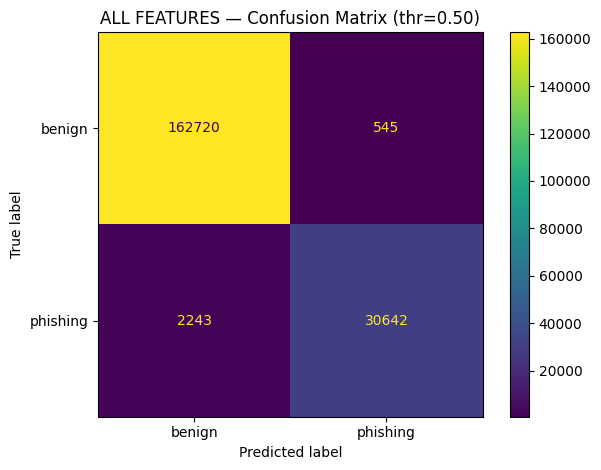

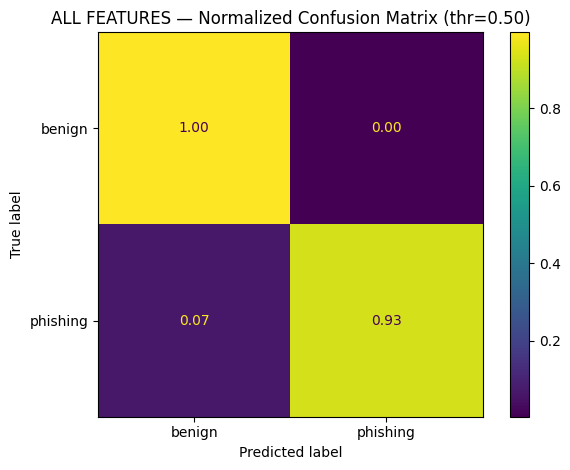

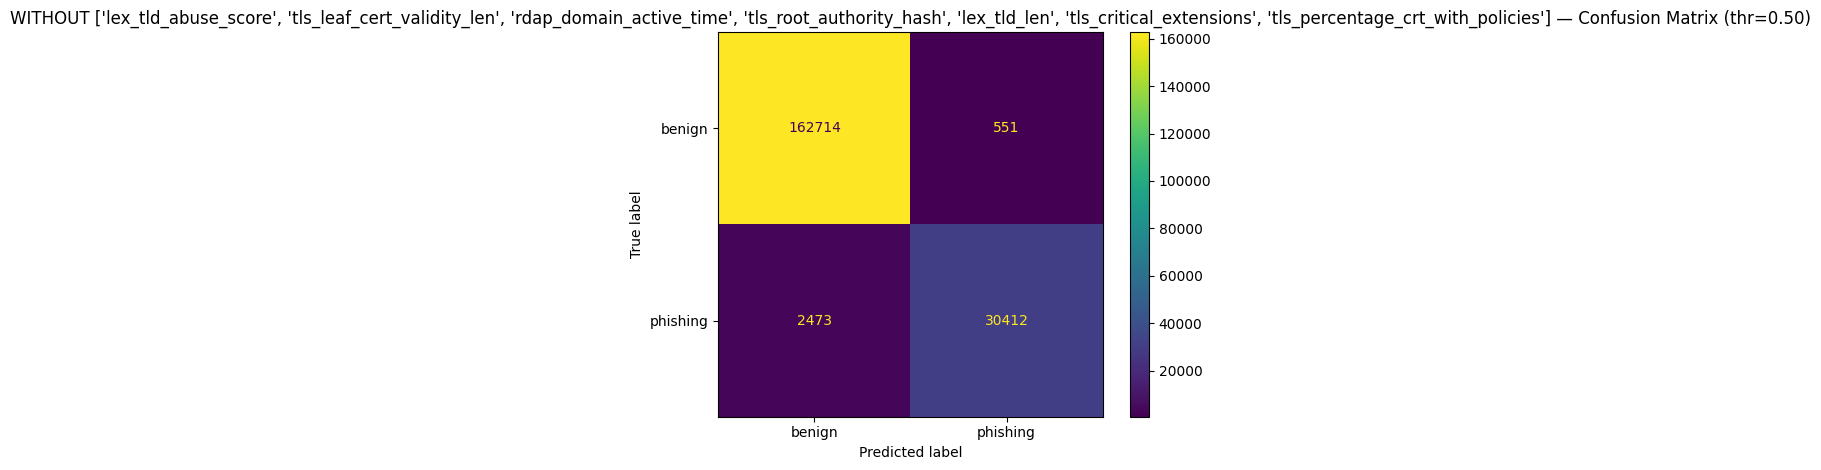

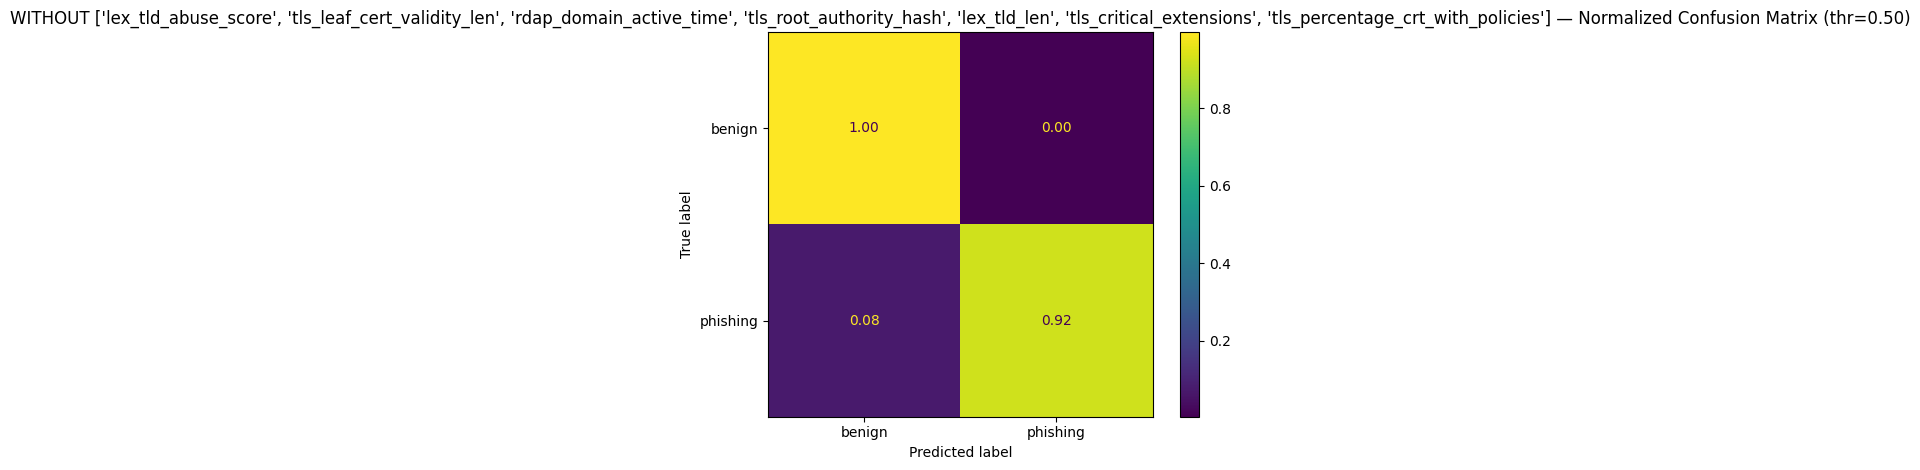

In [12]:
# Adjust if you use different target-name mapping
TARGET_NAMES = ["benign", "phishing"]
THRESHOLD = 0.5  # change if you prefer a different cutoff

def plot_cms(model, X, name, threshold=0.5):
    proba = model.predict_proba(X.loc[idx_test])[:, 1]
    preds = (proba >= threshold).astype(int)

    y_true = y.loc[idx_test]

    # Raw counts
    cm = confusion_matrix(y_true, preds, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
    disp.plot(values_format="d")
    plt.title(f"{name} — Confusion Matrix (thr={threshold:.2f})")
    plt.tight_layout()
    plt.show()

    # Normalized by true class
    cm_norm = confusion_matrix(y_true, preds, labels=[0, 1], normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=TARGET_NAMES)
    disp.plot(values_format=".2f")
    plt.title(f"{name} — Normalized Confusion Matrix (thr={threshold:.2f})")
    plt.tight_layout()
    plt.show()

# Plot for both models
plot_cms(model_all,  X_all,  "ALL FEATURES",      threshold=THRESHOLD)
plot_cms(model_drop, X_drop, f"WITHOUT {PROBLEM_FEATURES}", threshold=THRESHOLD)


##  6. Test on problematic benign domains

In [14]:
# --- edit these ---
FP_DATASET = "../testdata/xyz.parquet"
CORRECT_LABEL = "benign"  # all rows are benign in this file
TARGET_MAP = {"benign": 0, "phishing": 1}

# Load
df_fp = pq.read_table(FP_DATASET).to_pandas()
df_fp["label"] = CORRECT_LABEL

# (Optional) drop heavy columns you don’t use
# df_fp = df_fp.drop(columns=[c for c in df_fp.columns if c.startswith("html_")], errors="ignore")

# Map label to 0/1
df_fp["label"] = df_fp["label"].map(TARGET_MAP).astype("int8")
print(df_fp.shape, df_fp["label"].value_counts(dropna=False))


(949, 265) label
0    949
Name: count, dtype: int64


In [17]:
def get_model_feature_names(model):
    """Try to recover the feature names the model was trained with."""
    try:
        booster = model.get_booster()
        if getattr(booster, "feature_names", None):
            return list(booster.feature_names)
    except Exception:
        pass
    for attr in ("feature_name_", "feature_names_in_"):
        if hasattr(model, attr):
            return list(getattr(model, attr))
    # Pipelines: last step
    if hasattr(model, "steps"):
        try:
            return get_model_feature_names(model.steps[-1][1])
        except Exception:
            pass
    return None

def align_features(X: pd.DataFrame, required: list[str] | None, fill_value=np.nan) -> pd.DataFrame:
    """Reorder/add missing columns to match the model’s training schema."""
    X = X.copy()
    if required is None:
        return X
    for f in required:
        if f not in X.columns:
            X[f] = fill_value
    return X[required]

def plot_cm(y_true, y_pred, title):
    # Force 2x2 layout even if only benign is present
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign", "phishing"])
    disp.plot(values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [19]:
THRESHOLD = 0.5  # adjust if you want stricter/looser flagging

def evaluate_on_benign_only(model, df_fp, name: str):
    # Build raw features (drop label and optional identifier)
    drop_cols = [c for c in ("label", "domain_name") if c in df_fp.columns]
    X_raw = df_fp.drop(columns=drop_cols, errors="ignore")
    y_true = df_fp["label"]  # all zeros (benign)

    # Align to model’s training schema
    required = get_model_feature_names(model)
    X = align_features(X_raw, required, fill_value=np.nan)

    # Predict
    proba = model.predict_proba(X)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)

    # Since y_true is all 0, “correct”=TN, “incorrect”=FP
    tn = int((y_pred == 0).sum())
    fp = int((y_pred == 1).sum())
    total = len(y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) else 0.0

    print(f"\n=== {name} (benign-only) ===")
    print(f"Total benign: {total:,}")
    print(f"True Negatives (correct benign): {tn:,}")
    print(f"False Positives (benign flagged as phishing): {fp:,}")
    print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  FPR={fpr:.3f}")

    # Plot confusion matrix
    plot_cm(y_true, y_pred, f"{name} — Confusion Matrix on Benign-only (thr={THRESHOLD:.2f})")

    # List false-positive domains if available
    if "domain_name" in df_fp.columns:
        fp_domains = df_fp.loc[y_pred == 1, "domain_name"].tolist()
        print(f"False-positive domains (first 20 of {len(fp_domains)}): {fp_domains[:20]}")



=== ALL FEATURES (benign-only) ===
Total benign: 949
True Negatives (correct benign): 185
False Positives (benign flagged as phishing): 764
Accuracy=0.195  Precision=0.000  Recall=0.000  F1=0.000  FPR=0.805


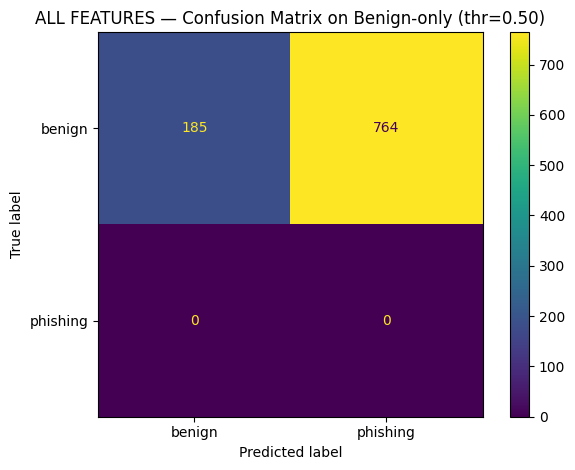

False-positive domains (first 20 of 764): ['10bdmbet43.com', '11pornxxx.com', '123hdd.com', '123sss.net', '13d0jwj0azfgtb0ipfqp7xm.com', '14pg2.com', '14pg8.com', '168topgameb.com', '1hzaqfiu8ctr.com', '1x7bet.xyz', '2588989.com', '2aksestukul.pro', '2wgaming.com', '3121629-cy97423.twc1.net', '3patticrown.net', '42pg10.com', '48ninecasino16.com', '4iki.net', '53pgdd.com', '5671602.xyz']

=== WITHOUT FEATURES (benign-only) ===
Total benign: 949
True Negatives (correct benign): 669
False Positives (benign flagged as phishing): 280
Accuracy=0.705  Precision=0.000  Recall=0.000  F1=0.000  FPR=0.295


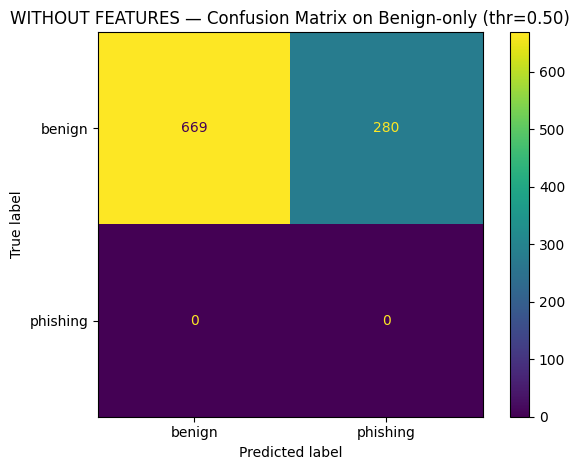

False-positive domains (first 20 of 280): ['14pg2.com', '14pg8.com', '2aksestukul.pro', '3121629-cy97423.twc1.net', '42pg10.com', '48ninecasino16.com', '53pgdd.com', '599k11.com', '66uba.com', '67spinmama42.com', '72pgdd.com', '777boijogo.com', '8toptrend.com', '95cemara777.com', '99004001.com', '99tg9e.com', 'aceh4dterbaik.pro', 'adzkialearningcenter.com', 'aethrascans.com', 'agen89pizza.com']


In [21]:
# assumes you already trained earlier: model_all, model_drop
evaluate_on_benign_only(model_all,  df_fp, "ALL FEATURES")
evaluate_on_benign_only(model_drop, df_fp, f"WITHOUT FEATURES")